<a href="https://colab.research.google.com/github/Gowdham-Kumar-C-dev/ML_with_scikit/blob/main/Tesla_Stock_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import math
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
from google.colab import files

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import LSTM
from tensorflow.keras.layers import Dropout
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import train_test_split




In [3]:
uploads=files.upload()

Saving TSLA.csv to TSLA.csv


In [4]:
df=pd.read_csv("TSLA.csv", parse_dates=True, index_col="Date")

In [5]:
df.head()

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2021-01-04,239.820007,248.163330,239.063339,243.256668,243.256668,145914600
2021-01-05,241.220001,246.946671,239.733337,245.036667,245.036667,96735600
2021-01-06,252.830002,258.000000,249.699997,251.993332,251.993332,134100000
2021-01-07,259.209991,272.329987,258.399994,272.013336,272.013336,154496700
2021-01-08,285.333344,294.829987,279.463318,293.339996,293.339996,225166500


In [6]:
df.describe()

,Open,High,Low,Close,Adj Close,Volume
count,755.000000,755.000000,755.000000,755.000000,755.000000,7.550000e+02
mean,247.110283,252.528238,241.192238,246.902755,246.902755,1.020998e+08
std,55.719476,56.923448,54.199330,55.512631,55.512631,4.209491e+07
min,103.000000,111.750000,101.809998,108.099998,108.099998,2.940180e+07
25%,210.125000,217.114998,205.940002,211.561668,211.561668,6.988095e+07
50%,242.050003,247.000000,236.979996,242.399994,242.399994,9.531300e+07
75%,279.946670,284.654999,272.850006,279.791672,279.791672,1.235995e+08
max,411.470001,414.496674,405.666656,409.970001,409.970001,3.065906e+08


In [7]:
print(df.shape)
df.info()

(755, 6)
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 755 entries, 2021-01-04 to 2024-01-03
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Open       755 non-null    float64
 1   High       755 non-null    float64
 2   Low        755 non-null    float64
 3   Close      755 non-null    float64
 4   Adj Close  755 non-null    float64
 5   Volume     755 non-null    int64  
dtypes: float64(5), int64(1)
memory usage: 41.3 KB


# **DATA** **VISUALIZATION**

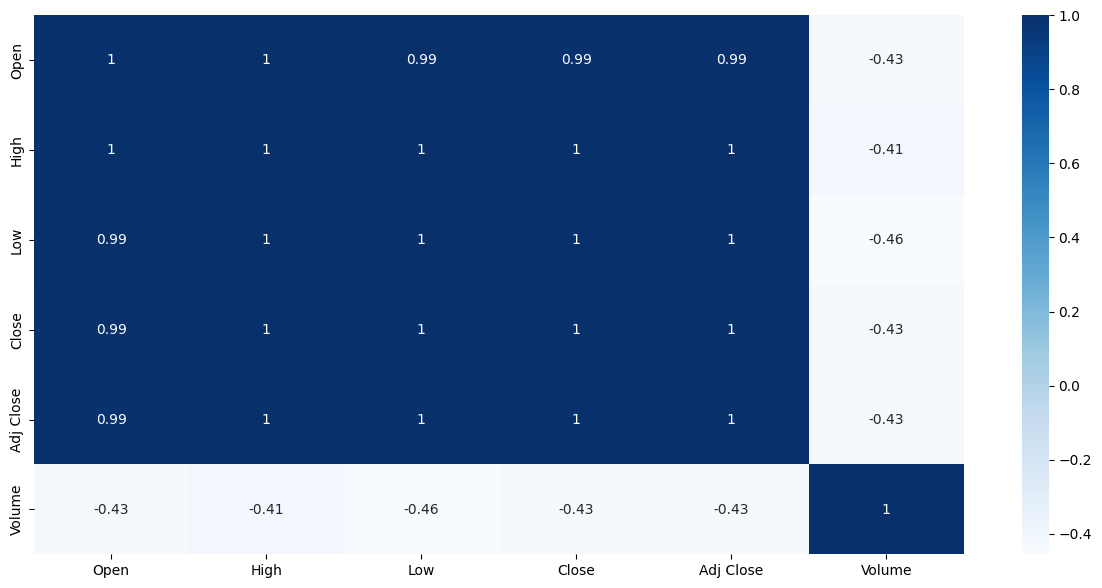

In [8]:
plt.figure(figsize=(15,7))
sns.heatmap(df.corr(),cbar=True,annot=True,cmap="Blues")
plt.show()

Text(0, 0.5, 'Close price $')

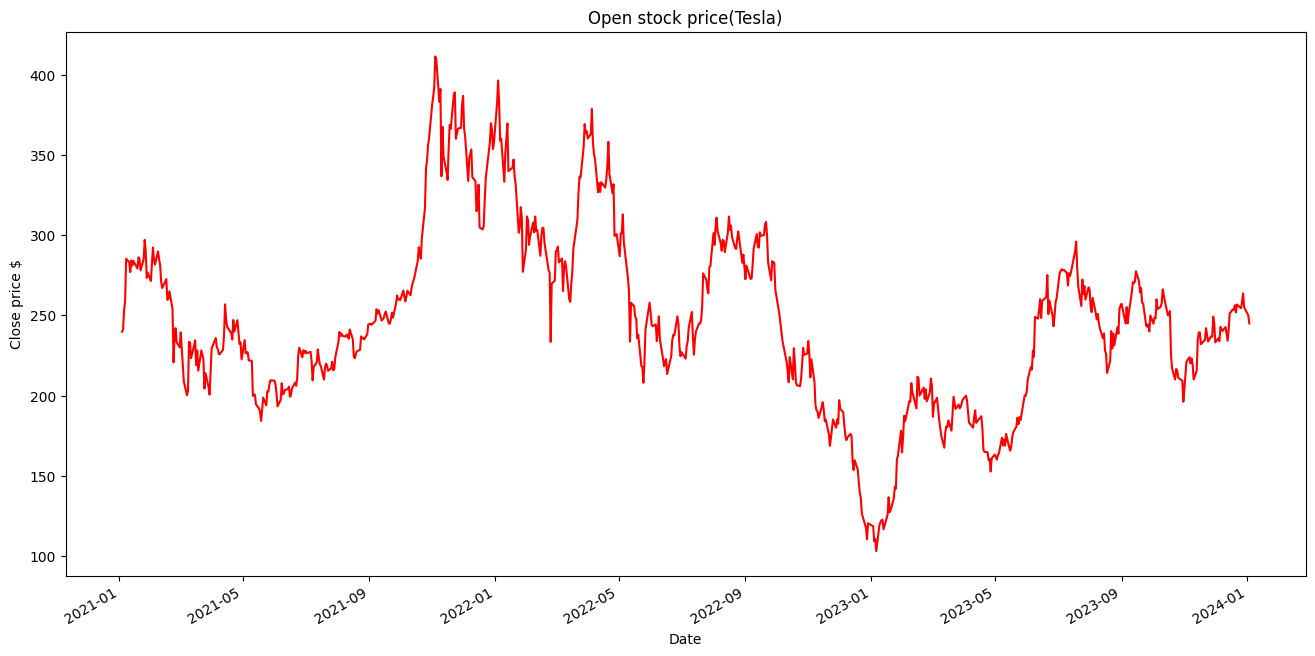

In [9]:
df["Open"].plot(figsize=(16,8),color='red')
plt.title("Open stock price(Tesla)")
plt.xlabel('Date')
plt.ylabel('Close price $')

[103.       109.110001 110.349998 110.510002 116.550003 117.5
 118.470001 118.959999 119.949997 120.389999 121.07     122.089996
 122.559998 125.699997 126.370003 127.260002 128.679993 135.869995
 136.       136.559998 139.339996 141.910004 143.       146.050003
 152.639999 153.440002 154.       159.25     159.639999 159.820007
 159.970001 160.009995 160.289993 160.899994 161.880005 162.429993
 162.710007 163.169998 163.970001 164.570007 164.649994 164.800003
 165.649994 166.169998 167.460007 167.660004 168.410004 168.630005
 168.699997 168.949997 172.199997 172.550003 173.570007 173.720001
 173.839996 173.889999 174.220001 174.869995 175.029999 175.130005
 175.850006 176.070007 176.100006 177.169998 177.309998 178.050003
 178.080002 179.100006 179.940002 179.960007 180.25     180.369995
 180.699997 180.800003 181.220001 182.229996 182.429993 182.960007
 183.080002 183.949997 183.949997 183.960007 184.183334 184.520004
 184.619995 184.990005 185.039993 185.050003 185.059998 186.
 186.1

Text(0, 0.5, 'Frequency')

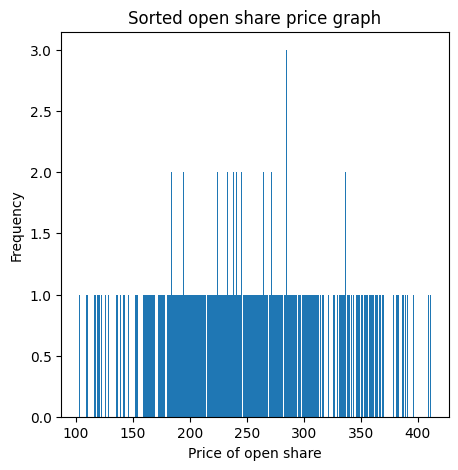

In [13]:
print(np.sort(df['Open']),"Sorted data of open share price")
plt.figure(figsize=(5,5))
open_prices_counts = df["Open"].value_counts().sort_index()
plt.bar(open_prices_counts.index, open_prices_counts.values)
plt.title("Sorted open share price graph")
plt.xlabel("Price of open share")
plt.ylabel("Frequency")

##DATA PREPROCESSING

In [14]:
df.isna().any()

,0
Open,False
High,False
Low,False
Close,False
Adj Close,False
Volume,False


In [15]:
dataset=df["Open"]
dataset=pd.DataFrame(dataset)
data=dataset.values
data.shape

(755, 1)

In [26]:
scaler=MinMaxScaler(feature_range=(0,1))
scaled_data=scaler.fit_transform(data)

In [30]:
train_size=int(len(data)*.75)
test_size=len(data)-train_size
print("Train size: ",train_size,"Test size :",test_size)

train_data=scaled_data[:train_size,0:1]
test_data=scaled_data[train_size:,0:1]

Train size:  566 Test size : 189


In [31]:
train_data.shape,test_data.shape

((566, 1), (189, 1))

**Training Test**

In [47]:
x_train=[]
y_train=[]

for i in range(60,len(train_data)):
  x_train.append(train_data[i-60:i,0])
  y_train.append(train_data[i,0])

In [48]:
x_train,y_train=np.array(x_train),np.array(y_train)

In [49]:
x_train=np.reshape(x_train,(x_train.shape[0],x_train.shape[1],1))

In [50]:
x_train.shape,y_train.shape

((506, 60, 1), (506,))

In [51]:
model=Sequential()
model.add(LSTM(50,return_sequences=True, input_shape=(x_train.shape[1],1)))
model.add(LSTM(64,return_sequences=False))
model.add(Dense(32))
model.add(Dense(16))
model.add(Dense(1))

model.compile(optimizer= 'adam', loss='mse',metrics=['mean_squared_error'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [41]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 60, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 64)             │        29,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 42,465 (165.88 KB)

 Trainable params: 42,465 (165.88 KB)

 Non-trainable params: 0 (0.00 B)

In [52]:
callbacks=[EarlyStopping(monitor='loss',patience=10,restore_best_weights=True)]
history=model.fit(x_train,y_train,epochs=100,batch_size=32,callbacks=callbacks)

Epoch 1/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 6s 66ms/step - loss: 0.0528 - mean_squared_error: 0.0528
Epoch 2/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - loss: 0.0118 - mean_squared_error: 0.0118
Epoch 3/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - loss: 0.0085 - mean_squared_error: 0.0085
Epoch 4/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - loss: 0.0056 - mean_squared_error: 0.0056
Epoch 5/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - loss: 0.0049 - mean_squared_error: 0.0049
Epoch 6/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - loss: 0.0046 - mean_squared_error: 0.0046
Epoch 7/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - loss: 0.0042 - mean_squared_error: 0.0042
Epoch 8/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - loss: 0.0039 - mean_squared_error: 0.0039
Epoch 9/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - loss: 0.0036 - mean_squared_error: 0.0036
Epoch 10/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - loss: 0.0035 - mean_squared_error: 0.0035
Epoch 11/100
16/16 ━━━━━━━━━━━━━━━━━━━━

##Visualization

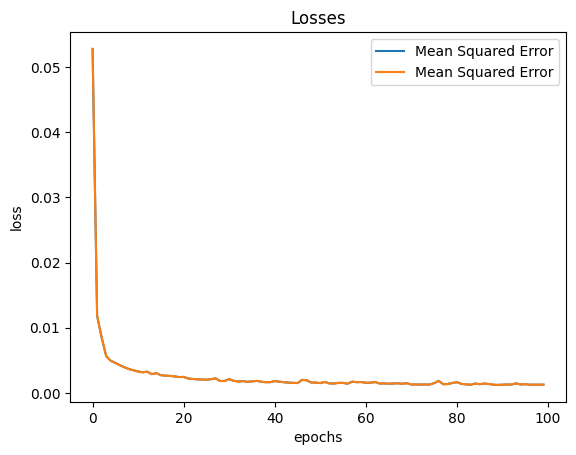

In [53]:
plt.plot(history.history["loss"])
plt.plot(history.history["mean_squared_error"])
plt.legend(['Mean Squared Error','Mean Squared Error'])
plt.title("Losses")
plt.xlabel("epochs")
plt.ylabel("loss")
plt.show()

##Testing set

In [56]:
x_test=[]
y_test=[]

for i in range(60,len(test_data)):
  x_test.append(test_data[i-60:i,0])
  y_test.append(test_data[i,0])
x_test,y_test=np.array(x_test),np.array(y_test)
x_test=np.reshape(x_test, (x_test.shape[0],x_test.shape[1],1))

In [57]:
x_test.shape,y_test.shape

((129, 60, 1), (129,))

##Prediction Test

In [60]:
prediction=model.predict(x_test)

prediction=scaler.inverse_transform(prediction)
prediction.shape

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


(129, 1)

In [61]:
y_test = y_test.reshape(-1, 1)
y_test=scaler.inverse_transform(y_test)

RMSE=np.sqrt(np.mean(y_test-prediction)**2).round(2)
RMSE

np.float64(1.37)

Visual

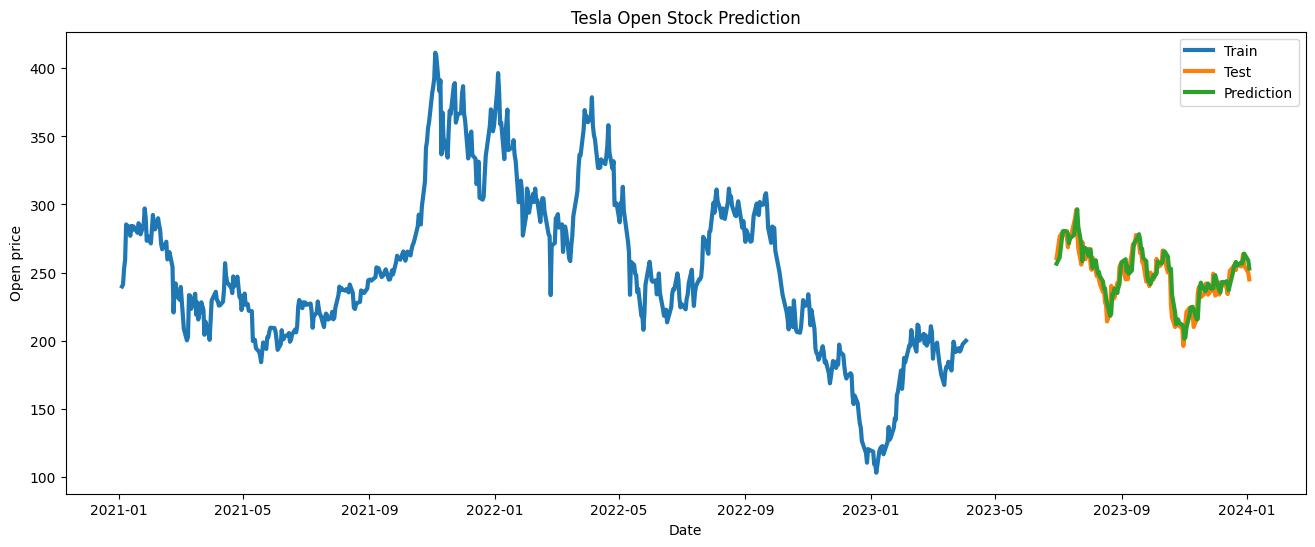

In [63]:
train=dataset.iloc[:train_size,0:1]
test=dataset.iloc[train_size + 60:,0:1]
test['Prediction']=prediction

plt.figure(figsize=(16,6))
plt.title('Tesla Open Stock Prediction')
plt.xlabel('Date')
plt.ylabel('Open price')
plt.plot(train['Open'],linewidth=3)
plt.plot(test['Open'],linewidth=3)
plt.plot(test["Prediction"],linewidth=3)
plt.legend(['Train','Test','Prediction'])